In [1]:
pip install numpy matplotlib

  Using cached numpy-2.3.4-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp311-cp311-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached numpy-2.3.4-cp311-cp311-win_amd64.whl (13.1 MB)
Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl (73 kB)
Using cached pillow-12.0.0-cp311-cp311-win_amd64.wh

In [1]:
# --------------------------------------------------------------
# 1. Load libraries
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [22]:
# --------------------------------------------------------------
# 2. Load the .npz file (all splits are inside)
# --------------------------------------------------------------
data = np.load('dermamnist.npz', allow_pickle=True)

# MedMNIST v2 menyimpan data dalam bentuk:
#   train_images, train_labels
#   val_images,   val_labels
#   test_images,  test_labels
train_img = data['train_images']
train_lbl = data['train_labels'].ravel()
val_img   = data['val_images']
val_lbl   = data['val_labels'].ravel()
test_img  = data['test_images']
test_lbl  = data['test_labels'].ravel()

In [23]:
# --------------------------------------------------------------
# 3. Gabungkan SEMUA gambar & label menjadi satu dataset
# --------------------------------------------------------------
all_images = np.concatenate([train_img, val_img, test_img], axis=0)
all_labels = np.concatenate([train_lbl, val_lbl, test_lbl], axis=0)

print(f"Total samples : {all_images.shape[0]}")
print(f"Image shape   : {all_images.shape[1:]}")   # (28, 28)

Total samples : 10015
Image shape   : (28, 28, 3)



=== CLASS DISTRIBUTION (ALL DATA) ===
Class 0 (akiec):  327 samples (0.0327 |  3.27%)
Class 1 (bcc):  514 samples (0.0513 |  5.13%)
Class 2 (bkl): 1099 samples (0.1097 | 10.97%)
Class 3 (df):  115 samples (0.0115 |  1.15%)
Class 4 (mel): 1113 samples (0.1111 | 11.11%)
Class 5 (nv): 6705 samples (0.6695 | 66.95%)
Class 6 (vasc):  142 samples (0.0142 |  1.42%)


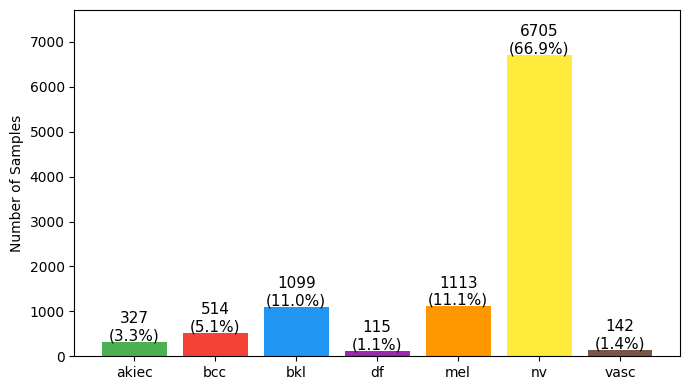

In [24]:
# --------------------------------------------------------------
# 4. Distribusi kelas & proporsi
# --------------------------------------------------------------
label_names = [
    'akiec', 'bcc', 'bkl', 'df',
    'mel', 'nv', 'vasc'
]
class_counts = Counter(all_labels)
total = len(all_labels)

print("\n=== CLASS DISTRIBUTION (ALL DATA) ===")
for lbl, cnt in sorted(class_counts.items()):
    prop = cnt / total
    print(f"Class {lbl} ({label_names[lbl]}): {cnt:4d} samples "
          f"({prop:.4f} | {prop*100:5.2f}%)")

# Visualisasi distribusi
plt.figure(figsize=(7, 4))
bars = plt.bar(label_names,
               [class_counts[i] for i in range(len(label_names))],
               color = [
                    '#4CAF50',  # Green
                    '#F44336',  # Red
                    '#2196F3',  # Blue
                    '#9C27B0',  # Purple
                    '#FF9800',  # Orange
                    '#FFEB3B',  # Yellow
                    '#795548'   # Brown
                ])
# plt.title('Class Distribution – PneumoniaMNIST v2 (All Data)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Samples')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 30,
             f'{int(yval)}\n({yval/total*100:.1f}%)',
             ha='center', fontsize=11)
plt.ylim(0, max(class_counts.values())*1.15)
plt.tight_layout()
plt.show()

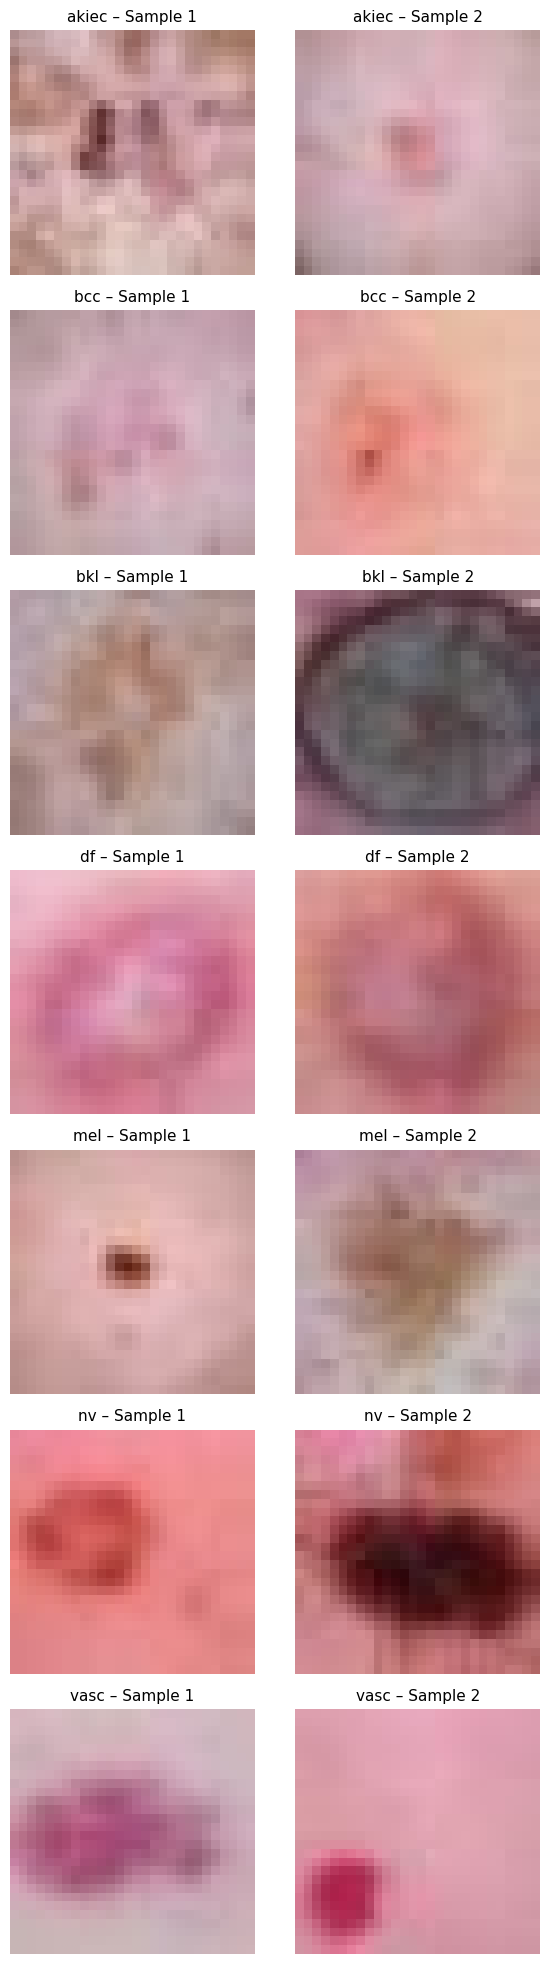

In [25]:
# --------------------------------------------------------------
# 5. Tampilkan 2 contoh gambar per kelas
# --------------------------------------------------------------
unique_classes = np.unique(all_labels)      # [0, 1]
n_samples_per_class = 2

fig, axes = plt.subplots(nrows=len(unique_classes),
                         ncols=n_samples_per_class,
                         figsize=(3*n_samples_per_class, 3*len(unique_classes)))
# fig.suptitle('Sample Images per Class (All Data)', fontsize=15, fontweight='bold')

for row, cls in enumerate(unique_classes):
    # Ambil indeks acak dari kelas tersebut
    idx_class = np.where(all_labels == cls)[0]
    np.random.seed(42)                     # reproducibility
    chosen = np.random.choice(idx_class, n_samples_per_class, replace=False)

    for col in range(n_samples_per_class):
        ax = axes[row, col] if len(unique_classes) > 1 else axes[col]
        ax.imshow(all_images[chosen[col]], cmap='gray')
        ax.set_title(f'{label_names[cls]} – Sample {col+1}', fontsize=11)
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [17]:
pip install pandas scipy

  Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl (11.3 MB)
Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl (38.7 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [scipy]
   -------------------- ---------------

In [41]:
# --------------------------------------------------------------
# 6. PEMBAGIAN LOGIS: MIN 100/33/20 PER KELAS + SISA DIRICHLET
# --------------------------------------------------------------
np.random.seed(42)

# --- Target minimal per client per kelas ---
min_per_client = [20, 33, 20]  # Client 1, 2, 3
n_clients = 3

# --- Hitung ukuran client (LogNormal) ---
n_total = len(all_images)
client_sizes_raw = np.random.lognormal(7.0, 0.5, n_clients)
client_sizes = np.round(client_sizes_raw / client_sizes_raw.sum() * n_total).astype(int)

# Koreksi: minimal = 300 + sum(min_per_client) per kelas
min_client_sizes = [300 + 7 * m for m in min_per_client]
client_sizes = [max(client_sizes[i], min_client_sizes[i]) for i in range(n_clients)]

diff = n_total - sum(client_sizes)
if diff > 0:
    for _ in range(diff):
        idx = np.argmin(client_sizes)
        client_sizes[idx] += 1
elif diff < 0:
    for _ in range(abs(diff)):
        idx = np.argmax(client_sizes)
        if client_sizes[idx] > min_client_sizes[idx]:
            client_sizes[idx] -= 1

# --- Cek kelayakan: cukup untuk min_per_client? ---
for c in range(7):
    total_needed = sum(min_per_client)
    if class_counts[c] < total_needed:
        print(f"Warning: Class {c} hanya {class_counts[c]} < {total_needed} → akan disesuaikan!")

# --- Alokasi MINIMUM dulu ---
idx_by_class = [np.where(all_labels == c)[0].tolist() for c in range(7)]
for arr in idx_by_class:
    np.random.shuffle(arr)

client_indices = [[] for _ in range(n_clients)]
ptr = [0] * 7

# Langkah 1: Beri minimal ke tiap client
for i in range(n_clients):
    for c in range(7):
        need = min_per_client[i]
        available = len(idx_by_class[c]) - ptr[c]
        take = min(need, available)
        client_indices[i].extend(idx_by_class[c][ptr[c]: ptr[c] + take])
        ptr[c] += take

# --- Sisa data per kelas ---
remaining_per_class = [len(idx_by_class[c]) - ptr[c] for c in range(7)]
total_remaining = sum(remaining_per_class)

# --- Ukuran sisa per client ---
remaining_sizes = [client_sizes[i] - len(client_indices[i]) for i in range(n_clients)]
remaining_sizes = [max(0, s) for s in remaining_sizes]

# --- Bagi sisa dengan Dirichlet (non-IID) ---
if total_remaining > 0:
    raw_props = np.random.dirichlet([0.3] * n_clients, size=7)  # (7, 3)
    raw_props = raw_props / raw_props.sum(axis=0, keepdims=True)
    
    extra_counts = np.zeros((n_clients, 7), dtype=int)
    for c in range(7):
        props = raw_props[c]
        extra = np.round(props / props.sum() * remaining_per_class[c]).astype(int)
        extra = np.clip(extra, 0, remaining_per_class[c])
        diff = remaining_per_class[c] - extra.sum()
        if diff > 0:
            idx = np.argmax(extra)
            extra[idx] += diff
        extra_counts[:, c] = extra
    
    # Koreksi ukuran sisa
    for i in range(n_clients):
        current_extra = extra_counts[i].sum()
        target = remaining_sizes[i]
        diff = target - current_extra
        if diff != 0:
            # Tambah/kurang dari kelas terbanyak
            idx = np.argmax(extra_counts[i]) if diff > 0 else np.argmin(extra_counts[i])
            if diff > 0 or (diff < 0 and extra_counts[i, idx] > 0):
                extra_counts[i, idx] += diff

    # Alokasi sisa
    for i in range(n_clients):
        for c in range(7):
            take = extra_counts[i, c]
            if take > 0:
                start = ptr[c]
                client_indices[i].extend(idx_by_class[c][start: start + take])
                ptr[c] += take

# --- Acak ulang tiap client ---
for i in range(n_clients):
    np.random.shuffle(client_indices[i])
    client_indices[i] = np.array(client_indices[i])

# --- Simpan ---
client_1 = {'images': all_images[client_indices[0]], 'labels': all_labels[client_indices[0]]}
client_2 = {'images': all_images[client_indices[1]], 'labels': all_labels[client_indices[1]]}
client_3 = {'images': all_images[client_indices[2]], 'labels': all_labels[client_indices[2]]}

In [43]:
# --------------------------------------------------------------
# 7. Validasi & Tampilkan
# --------------------------------------------------------------
clients = [client_1, client_2, client_3]
for i, client in enumerate(clients, 1):
    labels = client['labels']
    total = len(labels)
    min_req = min_per_client[i-1]
    print(f"\nclient_{i} | N={total:4d}")
    for c in range(7):
        cnt = np.sum(labels == c)
        prop = cnt / total
        print(f"  Class {c} ({label_names[c].split(' ')[0]:<6}): {cnt:4d} ({prop*100:5.1f}%)")
    # Validasi ketat
    assert all(np.sum(labels == c) >= min_req for c in range(7)), \
        f"client_{i} GAGAL: ada kelas < {min_req}!"


client_1 | N=3569
  Class 0 (akiec ):  183 (  5.1%)
  Class 1 (bcc   ):   20 (  0.6%)
  Class 2 (bkl   ):  550 ( 15.4%)
  Class 3 (df    ):   21 (  0.6%)
  Class 4 (mel   ):   28 (  0.8%)
  Class 5 (nv    ): 2717 ( 76.1%)
  Class 6 (vasc  ):   50 (  1.4%)

client_2 | N=1615
  Class 0 (akiec ):   84 (  5.2%)
  Class 1 (bcc   ):   35 (  2.2%)
  Class 2 (bkl   ):  319 ( 19.8%)
  Class 3 (df    ):   39 (  2.4%)
  Class 4 (mel   ): 1065 ( 65.9%)
  Class 5 (nv    ):   35 (  2.2%)
  Class 6 (vasc  ):   38 (  2.4%)

client_3 | N=4831
  Class 0 (akiec ):   60 (  1.2%)
  Class 1 (bcc   ):  459 (  9.5%)
  Class 2 (bkl   ):  230 (  4.8%)
  Class 3 (df    ):   55 (  1.1%)
  Class 4 (mel   ):   20 (  0.4%)
  Class 5 (nv    ): 3953 ( 81.8%)
  Class 6 (vasc  ):   54 (  1.1%)


In [44]:
# --------------------------------------------------------------
# 8. Uji Statistik: Chi-Square untuk Heterogenitas Label (7 KELAS)
# --------------------------------------------------------------
from scipy import stats

print("\n" + "-"*80)
print("UJI CHI-SQUARE: Homogeneity of Class Distributions (7 Kelas)")
print("-"*80)

# Buat contingency table: baris = client, kolom = kelas
contingency = np.zeros((3, 7), dtype=int)
for i in range(3):
    for c in range(7):
        contingency[i, c] = np.sum(clients[i]['labels'] == c)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic : {chi2:,.2f}")
print(f"p-value              : {p_chi2:.2e}")
print(f"Degrees of freedom   : {dof}")
print(f"Reject H0 (p < 0.05) : {'YES' if p_chi2 < 0.05 else 'NO'}")
if p_chi2 < 0.05:
    print("→ Distribusi kelas antar client BERBEDA SECARA SIGNIFIKAN (non-IID terbukti).")
else:
    print("→ Tidak cukup bukti perbedaan distribusi kelas.")


--------------------------------------------------------------------------------
UJI CHI-SQUARE: Homogeneity of Class Distributions (7 Kelas)
--------------------------------------------------------------------------------
Chi-square statistic : 7,288.59
p-value              : 0.00e+00
Degrees of freedom   : 12
Reject H0 (p < 0.05) : YES
→ Distribusi kelas antar client BERBEDA SECARA SIGNIFIKAN (non-IID terbukti).


In [46]:
# --------------------------------------------------------------
# 9. Uji KS pada Mean Pixel Intensity (Dengan Penanganan NaN & Error)
# --------------------------------------------------------------
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("\n" + "-"*80)
print("UJI KOLMOGOROV-SMIRNOV (KS): Distribusi Intensitas Rata-rata Piksel")
print("-"*80)

# Hitung mean pixel intensity per gambar → pastikan float & bersih dari NaN
mean_intensities = []
for c in clients:
    imgs = c['images'].astype(float)
    means = np.mean(imgs, axis=(1, 2))  # (N,)
    means = means[~np.isnan(means)]     # Hapus NaN (jika ada)
    if len(means) == 0:
        raise ValueError("Salah satu client kosong setelah filter NaN!")
    mean_intensities.append(means)

client_names = [f"client_{i+1}" for i in range(3)]

# Uji KS antar pasangan
sig_count = 0
total_pairs = 0
print(f"{'Pasangan':<18} {'N1':<6} {'N2':<6} {'KS Stat':<10} {'p-value':<12} {'Kesimpulan'}")
print("-" * 78)

for i in range(3):
    for j in range(i+1, 3):
        total_pairs += 1
        data1, data2 = mean_intensities[i], mean_intensities[j]
        try:
            ks_stat, p_ks = stats.ks_2samp(data1, data2)
            # Pastikan p_ks adalah scalar
            p_ks = float(p_ks)
        except Exception as e:
            print(f"Error pada {client_names[i]} vs {client_names[j]}: {e}")
            ks_stat, p_ks = 0.0, 1.0
        
        conclusion = "BERBEDA" if p_ks < 0.05 else "SAMA"
        if p_ks < 0.05:
            sig_count += 1
        
        print(f"{client_names[i]:<8} vs {client_names[j]:<8} "
              f"{len(data1):<6} {len(data2):<6} "
              f"{ks_stat:8.4f}   {p_ks:10.2e}   → {conclusion}")

# Ringkasan
print("-" * 78)
print(f"Pasangan signifikan (p < 0.05): {sig_count}/{total_pairs}")
if sig_count == total_pairs:
    print("SEMUA pasangan client memiliki DISTRIBUSI INTENSITAS BERBEDA (non-IID visual terbukti).")
elif sig_count > 0:
    print(f"{sig_count} pasangan menunjukkan perbedaan signifikan.")
else:
    print("Tidak ada bukti perbedaan distribusi intensitas antar client.")


--------------------------------------------------------------------------------
UJI KOLMOGOROV-SMIRNOV (KS): Distribusi Intensitas Rata-rata Piksel
--------------------------------------------------------------------------------
Pasangan           N1     N2     KS Stat    p-value      Kesimpulan
------------------------------------------------------------------------------
client_1 vs client_2 10707  4845     0.0900     5.65e-24   → BERBEDA
client_1 vs client_3 10707  14493    0.0203     1.22e-02   → BERBEDA
client_2 vs client_3 4845   14493    0.1013     7.01e-33   → BERBEDA
------------------------------------------------------------------------------
Pasangan signifikan (p < 0.05): 3/3
SEMUA pasangan client memiliki DISTRIBUSI INTENSITAS BERBEDA (non-IID visual terbukti).


In [29]:
pip install torch torchvision torchaudio scikit-learn numpy matplotlib seaborn

  Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
   ---------------------------------------- 0.8/109.3 MB 4.8 MB/s eta 0:00:23
    --------------------------------------- 1.8/109.3 MB 4.6 MB/s eta 0:00:24
    --------------------------------------- 2.6/109.3 MB 4.3 MB/s eta 0:00:25
   - -------------------------------------- 3.7/109.3 MB 4.4 MB/s eta 0:00:24
   - -------------------------------------- 5.2/109.3 MB 4.9 MB/s eta 

In [73]:
# --------------------------------------------------------------
# 10. FULL FEDERATED LEARNING PIPELINE (FIXED + FINAL VISUALIZATION)
#     - 5-Fold CV per Client (No Merging)
#     - 50 Rounds
#     - 4 FL Algorithms + Local
#     - Print: Rapi, vertikal
#     - Average 5 folds → Same print format
#     - PR Curve, ROC Curve, Confusion Matrix (normalized)
# --------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, precision_recall_curve, roc_curve, confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings("ignore")

# Seed
torch.manual_seed(42)
np.random.seed(42)

In [74]:
# --------------------------------------------------------------
# 10.1 CNN Ringan (RGB Input, 7 Kelas)
# --------------------------------------------------------------
class LightweightCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)   # ← RGB: 3 channel
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 7)                   # ← 7 kelas
        self.dropout = nn.Dropout(0.25)
    
    def forward(self, x):
        # x: (B, 28, 28, 3) → permute ke (B, 3, 28, 28)
        if x.dim() == 4 and x.shape[-1] == 3:
            x = x.permute(0, 3, 1, 2)
        x = x.float() / 255.0
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # logits
        return x

# Model
model = LightweightCNN()
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

LightweightCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=7, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)
Total parameters: 105,959


In [75]:
# --------------------------------------------------------------
# 10.2 Evaluation & Metrics (Multi-class, tetap pakai presisi, recall, f1 per kelas → macro)
# --------------------------------------------------------------
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            logits = model(Xb)
            prob = F.softmax(logits, dim=1).cpu().numpy()  # (B, 7)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            y_true.extend(yb.cpu().numpy().flatten())
            y_pred.extend(pred)
            y_prob.append(prob)
    y_prob = np.vstack(y_prob)
    return np.array(y_true), np.array(y_pred), y_prob

def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except:
        auc = 0.5
    try:
        logloss = log_loss(y_true, y_prob)
    except:
        logloss = -np.log(1.0 / 7)  # ≈1.946
    return {
        'akurasi': acc, 'presisi': prec, 'recall': rec,
        'f1_score': f1, 'roc_auc': auc, 'log_loss': logloss
    }

def train_local(model, loader, epochs=1, lr=0.01):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for Xb, yb in loader:
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb.long())
            loss.backward()
            optimizer.step()
    return model

In [76]:
# --------------------------------------------------------------
# 10.3 5-Fold CV + 4 Global Models
# --------------------------------------------------------------
clients = [client_1, client_2, client_3]
K = len(clients)
fold_results = {name: [] for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']}

# Store for curves (last round)
all_y_true = {name: [] for name in fold_results}
all_y_prob = {name: [] for name in fold_results}

for fold in range(5):
    print(f"\n{'='*70}")
    print(f"{' '*25} FOLD {fold+1}/5")
    print(f"{'='*70}")
    
    # Split per client
    train_loaders, test_loaders, client_sizes = [], [], []
    for client in clients:
        X, y = client['images'], client['labels']  # X: (N, 28, 28, 3)
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + fold)
        for train_idx, test_idx in skf.split(X, y):
            X_train = torch.tensor(X[train_idx], dtype=torch.float32)
            y_train = torch.tensor(y[train_idx], dtype=torch.long)
            X_test = torch.tensor(X[test_idx], dtype=torch.float32)
            y_test = torch.tensor(y[test_idx], dtype=torch.long)
            
            # PERMUTE: (N, H, W, C) → (N, C, H, W)
            X_train = X_train.permute(0, 3, 1, 2)
            X_test = X_test.permute(0, 3, 1, 2)
            
            train_loaders.append(DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True))
            test_loaders.append(DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False))
            client_sizes.append(len(train_idx))
            break
    total_n = sum(client_sizes)
    
    # Global models
    global_models = {name: copy.deepcopy(model) for name in ['fedavg', 'fedprox', 'fedsvrg', 'fedatt']}
    
    # Control variates
    params = list(model.parameters())
    c_global = {name: [torch.zeros_like(p) for p in params] for name in ['fedsvrg']}
    c_local = [[torch.zeros_like(p) for p in params] for _ in range(K)]
    
    round_metrics = {name: [] for name in fold_results}
    
    for round_num in range(1, 51):
        # Local training
        local_models = [train_local(copy.deepcopy(model), loader, epochs=1) for loader in train_loaders]
        local_params = [list(m.parameters()) for m in local_models]
        
        # LOCAL EVAL
        local_scores = []
        for i, loader in enumerate(test_loaders):
            yt, yp, ypr = evaluate_model(local_models[i], loader)
            local_scores.append(compute_metrics(yt, yp, ypr))
        local_avg = {k: np.mean([m[k] for m in local_scores]) for k in local_scores[0]}
        round_metrics['local'].append(local_avg)
        
        # 1. FedAvg
        w_avg = copy.deepcopy(global_models['fedavg'])
        for p in w_avg.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = client_sizes[i] / total_n
            for pg, pl in zip(w_avg.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedavg'] = w_avg
        
        # 2. FedProx
        w_prox = copy.deepcopy(global_models['fedprox'])
        for i, loader in enumerate(train_loaders):
            m = copy.deepcopy(w_prox)
            opt = optim.Adam(m.parameters(), lr=0.01)
            crit = nn.CrossEntropyLoss()
            for _ in range(3):
                for Xb, yb in loader:
                    opt.zero_grad()
                    out = m(Xb)
                    loss = crit(out, yb.long())
                    prox = 0.01/2 * sum((p-q).norm(2)**2 for p, q in zip(m.parameters(), w_prox.parameters()))
                    (loss + prox).backward()
                    opt.step()
            local_models[i] = m
        for p in w_prox.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = client_sizes[i] / total_n
            for pg, pl in zip(w_prox.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedprox'] = w_prox
        
        # 3. FedSVRG (SCAFFOLD)
        w_svrg = copy.deepcopy(global_models['fedsvrg'])
        w_params = list(w_svrg.parameters())
        for i, loader in enumerate(train_loaders):
            m = copy.deepcopy(w_svrg)
            m_params = list(m.parameters())
            opt = optim.Adam(m.parameters(), lr=0.01)
            crit = nn.CrossEntropyLoss()
            for _ in range(3):
                for Xb, yb in loader:
                    opt.zero_grad()
                    out = m(Xb)
                    loss = crit(out, yb.long())
                    loss.backward()
                    for j, (p, c_k, c_g) in enumerate(zip(m_params, c_local[i], c_global['fedsvrg'])):
                        if p.grad is not None:
                            p.grad = p.grad - c_k + c_g
                    opt.step()
            local_models[i] = m
            local_params[i] = m_params
        
        # Update control variates
        for j in range(len(w_params)):
            delta = sum((local_params[i][j] - w_params[j]) for i in range(K)) / K
            c_global['fedsvrg'][j] += delta
            for i in range(K):
                c_local[i][j] = c_global['fedsvrg'][j]
        
        # Aggregation
        for p in w_svrg.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = 1.0 / K
            for pg, pl in zip(w_svrg.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedsvrg'] = w_svrg
        
        # 4. FedAtt
        w_att = copy.deepcopy(global_models['fedatt'])
        sims = []
        for m in local_models:
            sim = sum(F.cosine_similarity(pg.flatten(), pl.flatten(), dim=0)
                      for pg, pl in zip(w_att.parameters(), m.parameters()))
            sims.append(sim.item())
        attn = F.softmax(torch.tensor(sims), dim=0)
        for p in w_att.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            for pg, pl in zip(w_att.parameters(), m.parameters()):
                pg.data += attn[i] * pl.data
        global_models['fedatt'] = w_att
        
        # GLOBAL EVAL
        for name in ['fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
            gmodel = global_models[name]
            scores = []
            y_true_all, y_prob_all = [], []
            for loader in test_loaders:
                yt, yp, ypr = evaluate_model(gmodel, loader)
                scores.append(compute_metrics(yt, yp, ypr))
                y_true_all.extend(yt)
                y_prob_all.extend(ypr)
            avg = {k: np.mean([m[k] for m in scores]) for k in scores[0]}
            round_metrics[name].append(avg)
            if round_num == 50:
                all_y_true[name].append(np.array(y_true_all))
                all_y_prob[name].append(np.array(y_prob_all))
        
        # Save local for curves
        if round_num == 50:
            yt_all, yp_all, ypr_all = [], [], []
            for i, loader in enumerate(test_loaders):
                yt, yp, ypr = evaluate_model(local_models[i], loader)
                yt_all.extend(yt); ypr_all.extend(ypr)
            all_y_true['local'].append(np.array(yt_all))
            all_y_prob['local'].append(np.array(ypr_all))
        
        # PRINT → FORMAT TETAP SAMA
        print(f"\n--- Round {round_num} ---")
        for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
            m = round_metrics[name][-1]
            print(f"{name.upper()} round {round_num}")
            print(f"  akurasi : {m['akurasi']:.4f}")
            print(f"  presisi : {m['presisi']:.4f}")
            print(f"  recall  : {m['recall']:.4f}")
            print(f"  f1_score: {m['f1_score']:.4f}")
            print(f"  roc_auc : {m['roc_auc']:.4f}")
            print(f"  log_loss: {m['log_loss']:.4f}")
    
    for name in round_metrics:
        fold_results[name].append(round_metrics[name])


                          FOLD 1/5

--- Round 1 ---
LOCAL round 1
  akurasi : 0.7464
  presisi : 0.1066
  recall  : 0.1429
  f1_score: 0.1219
  roc_auc : 0.7460
  log_loss: 0.9095
FEDAVG round 1
  akurasi : 0.5339
  presisi : 0.0763
  recall  : 0.1429
  f1_score: 0.0861
  roc_auc : 0.7005
  log_loss: 1.4748
FEDPROX round 1
  akurasi : 0.5339
  presisi : 0.0763
  recall  : 0.1429
  f1_score: 0.0861
  roc_auc : 0.7412
  log_loss: 1.4627
FEDSVRG round 1
  akurasi : 0.5339
  presisi : 0.0763
  recall  : 0.1429
  f1_score: 0.0861
  roc_auc : 0.6536
  log_loss: 1.5238
FEDATT round 1
  akurasi : 0.5339
  presisi : 0.0763
  recall  : 0.1429
  f1_score: 0.0861
  roc_auc : 0.6350
  log_loss: 1.5432

--- Round 2 ---
LOCAL round 2
  akurasi : 0.7464
  presisi : 0.1066
  recall  : 0.1429
  f1_score: 0.1219
  roc_auc : 0.7572
  log_loss: 0.8193
FEDAVG round 2
  akurasi : 0.5339
  presisi : 0.0763
  recall  : 0.1429
  f1_score: 0.0861
  roc_auc : 0.7229
  log_loss: 1.4373
FEDPROX round 2
  akurasi :


                          AVERAGE OF 5 FOLDS

--- Round 1 ---
LOCAL round 1
  Accuracy : 0.7444
  Precision: 0.1113
  Recall   : 0.1425
  F1-Score : 0.1220
  ROC-AUC  : 0.6814
  Log-Loss : 0.8444
FEDAVG round 1
  Accuracy : 0.5339
  Precision: 0.0763
  Recall   : 0.1429
  F1-Score : 0.0861
  ROC-AUC  : 0.6458
  Log-Loss : 1.4891
FEDPROX round 1
  Accuracy : 0.5339
  Precision: 0.0763
  Recall   : 0.1429
  F1-Score : 0.0861
  ROC-AUC  : 0.7172
  Log-Loss : 1.4723
FEDSVRG round 1
  Accuracy : 0.5339
  Precision: 0.0763
  Recall   : 0.1429
  F1-Score : 0.0861
  ROC-AUC  : 0.5598
  Log-Loss : 1.5901
FEDATT round 1
  Accuracy : 0.5339
  Precision: 0.0763
  Recall   : 0.1429
  F1-Score : 0.0861
  ROC-AUC  : 0.5462
  Log-Loss : 1.6044

--- Round 2 ---
LOCAL round 2
  Accuracy : 0.7464
  Precision: 0.1066
  Recall   : 0.1429
  F1-Score : 0.1219
  ROC-AUC  : 0.7399
  Log-Loss : 0.8054
FEDAVG round 2
  Accuracy : 0.5339
  Precision: 0.0763
  Recall   : 0.1429
  F1-Score : 0.0861
  ROC-AUC  : 0.

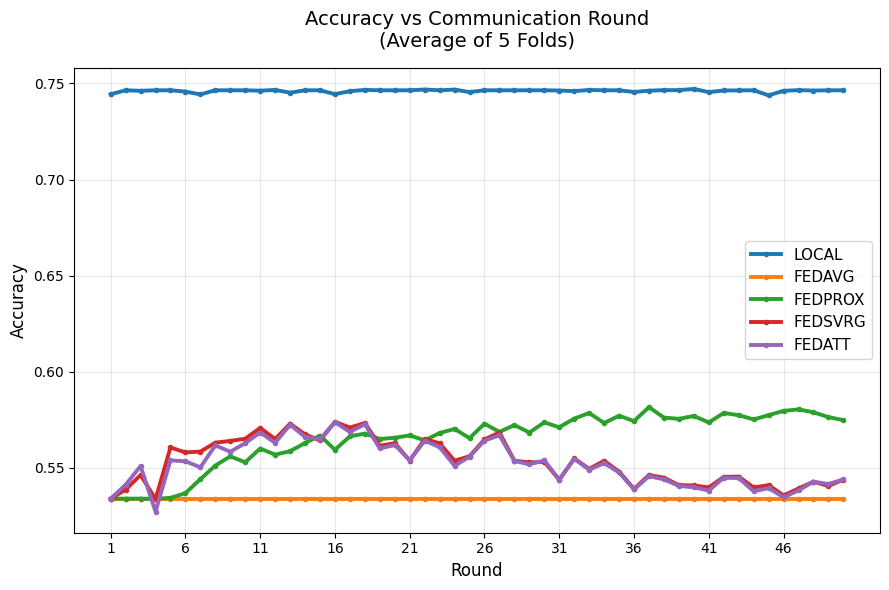

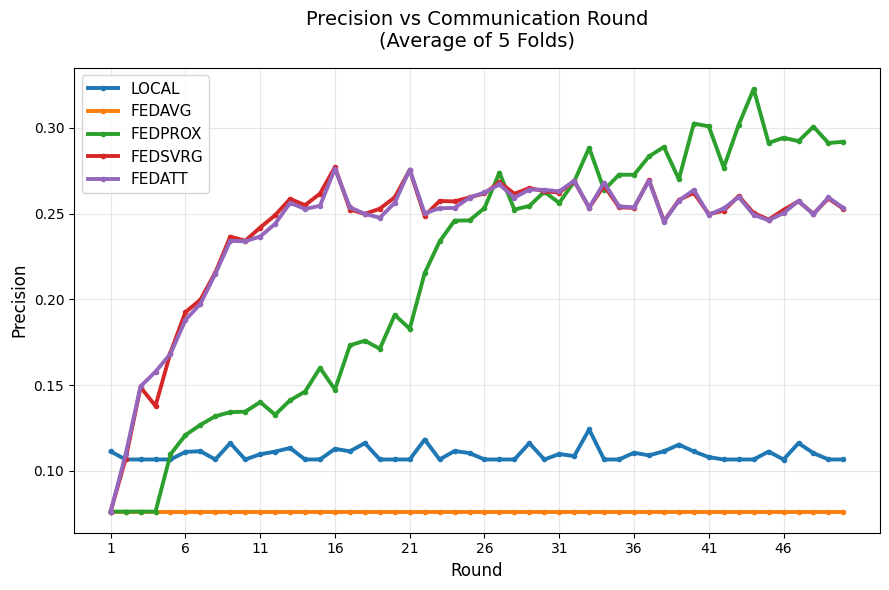

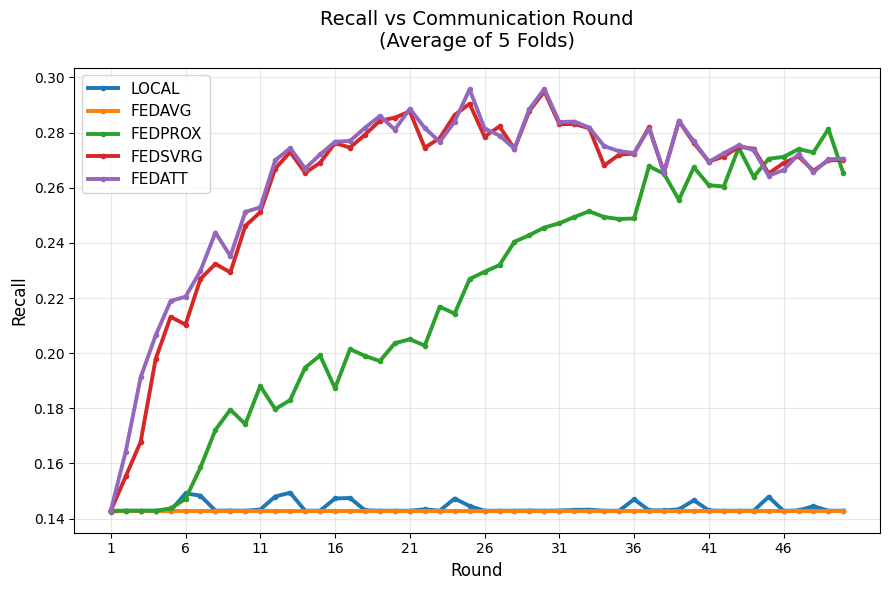

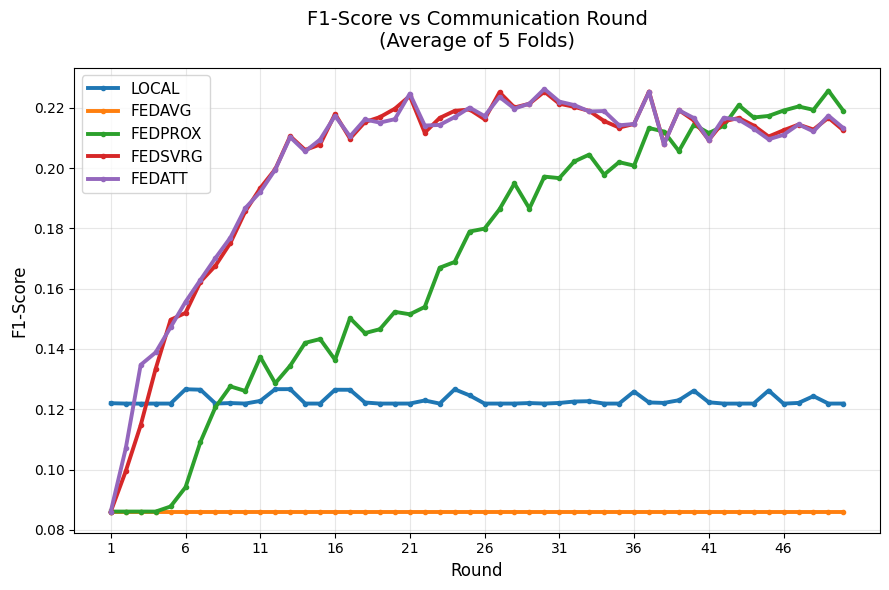

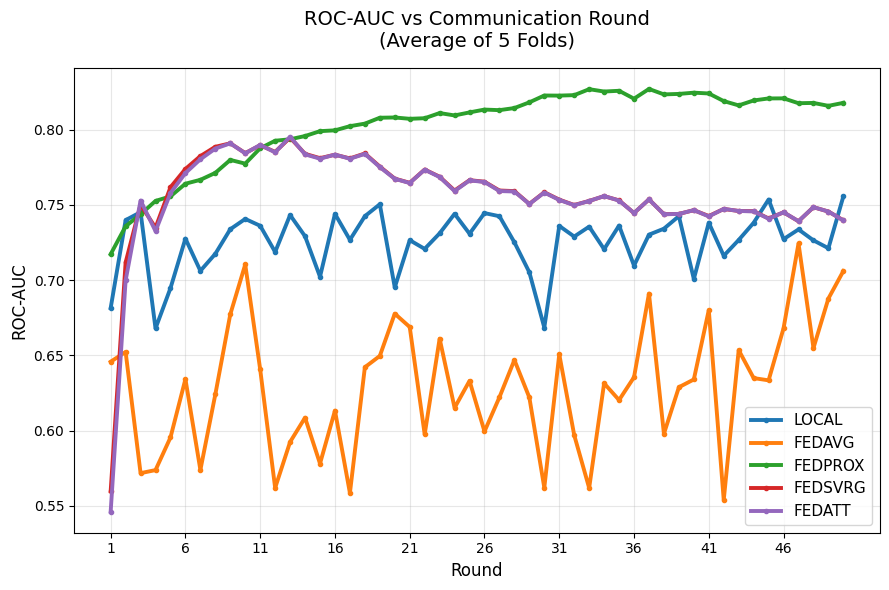

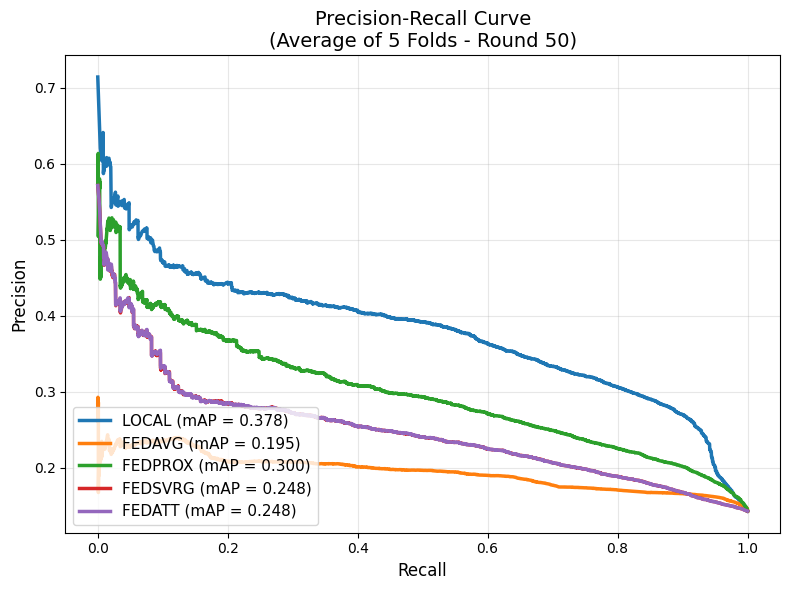

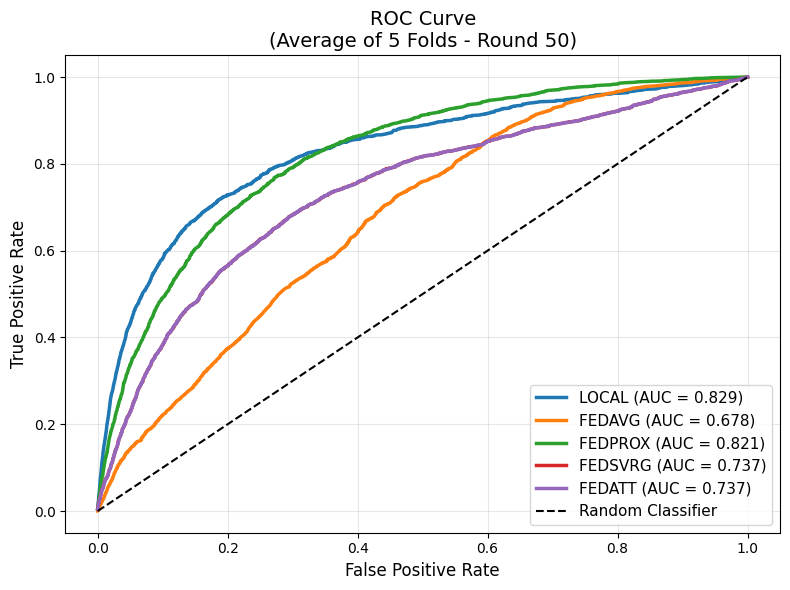

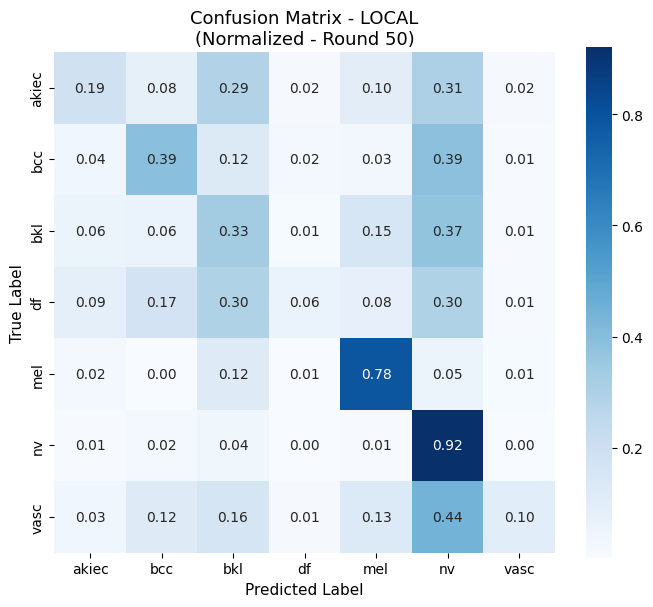

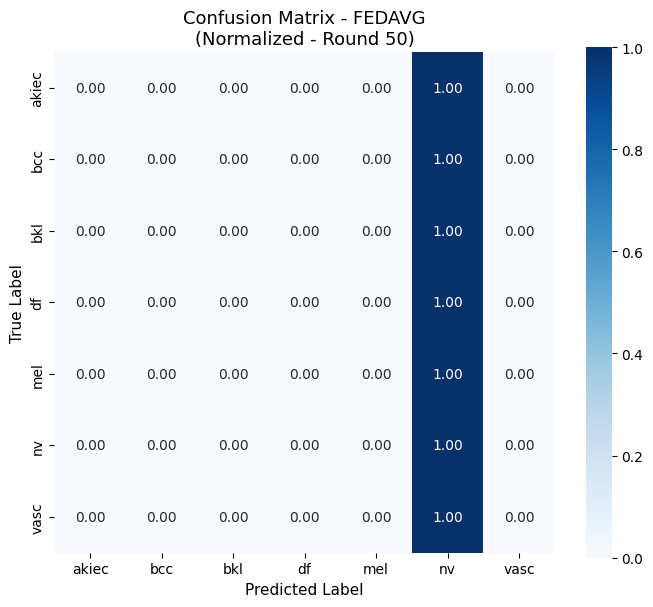

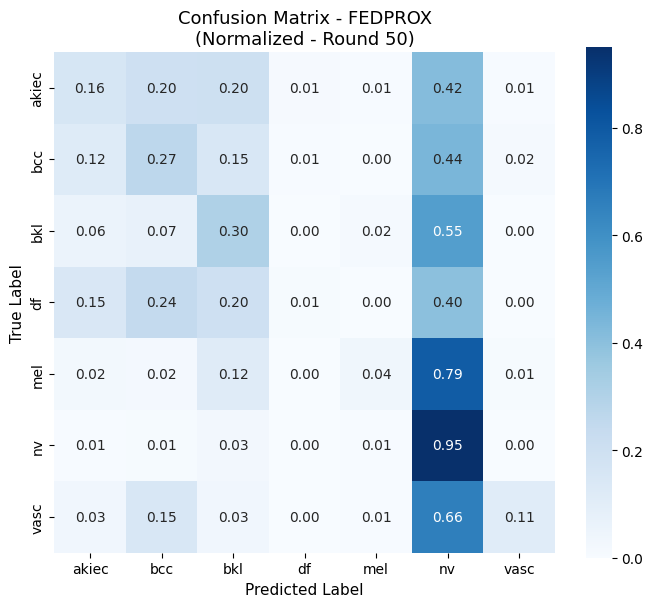

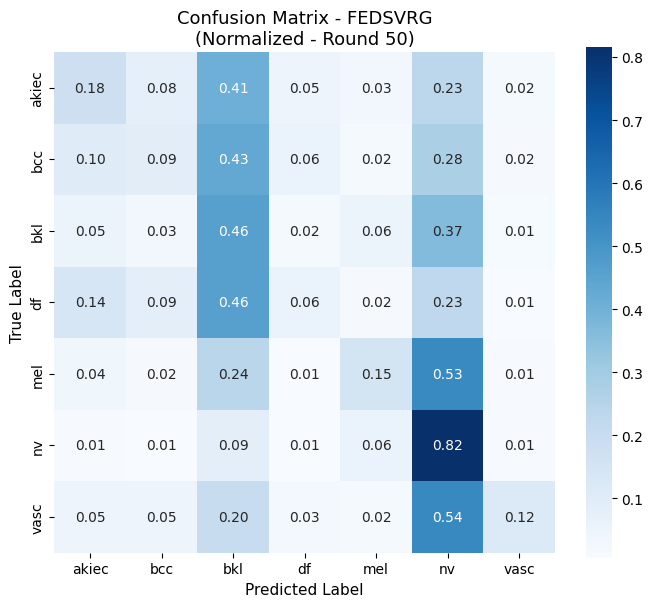

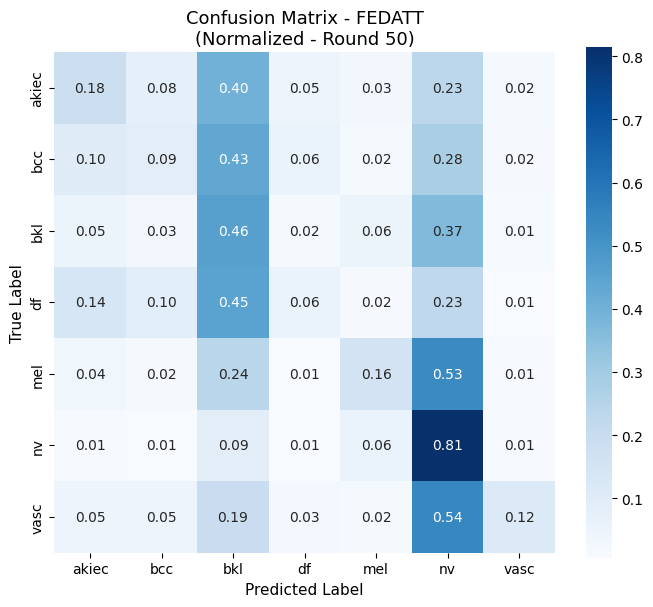


FINAL PERFORMANCE (Round 50 - Average of 5 Folds)
Model         Accuracy  Precision   Recall       F1      AUC     Loss
----------------------------------------------------------------------------------------------------
LOCAL        0.7464    0.1066     0.1429   0.1219   0.7556   0.7892
FEDAVG       0.5339    0.0763     0.1429   0.0861   0.7061   1.4642
FEDPROX      0.5747    0.2919     0.2652   0.2190   0.8178   1.5996
FEDSVRG      0.5438    0.2528     0.2700   0.2125   0.7397   2.4578
FEDATT       0.5439    0.2532     0.2705   0.2133   0.7396   2.4540


In [77]:
# --------------------------------------------------------------
# 11. AGGREGATION OF 5 FOLDS + FINAL VISUALIZATION (REVISED)
#     - Separate figures (1 image per plot)
#     - All in English
#     - Line plots: 1 metric per figure
#     - PR Curve: 1 figure (macro avg)
#     - ROC Curve: 1 figure (macro avg)
#     - Confusion Matrix: 5 separate figures (7x7)
# --------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, confusion_matrix, average_precision_score
import seaborn as sns

# === 1. Aggregate 5 Folds ===
avg_round = {name: [] for name in fold_results}
for name in fold_results:
    for r in range(50):
        round_data = [fold_results[name][f][r] for f in range(5)]
        avg = {k: np.mean([m[k] for m in round_data]) for k in round_data[0]}
        avg_round[name].append(avg)

# === 2. PRINT AVERAGE 5 FOLDS (ENGLISH) ===
print(f"\n{'='*70}")
print(f"{' '*25} AVERAGE OF 5 FOLDS")
print(f"{'='*70}")
for round_num in range(1, 51):
    print(f"\n--- Round {round_num} ---")
    for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
        m = avg_round[name][round_num-1]
        print(f"{name.upper()} round {round_num}")
        print(f"  Accuracy : {m['akurasi']:.4f}")
        print(f"  Precision: {m['presisi']:.4f}")
        print(f"  Recall   : {m['recall']:.4f}")
        print(f"  F1-Score : {m['f1_score']:.4f}")
        print(f"  ROC-AUC  : {m['roc_auc']:.4f}")
        print(f"  Log-Loss : {m['log_loss']:.4f}")

# === 3. LINE PLOTS: 1 METRIC PER FIGURE ===
metrics = ['akurasi', 'presisi', 'recall', 'f1_score', 'roc_auc', 'log_loss']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Log-Loss']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for met, title, color in zip(metrics, titles, colors):
    plt.figure(figsize=(9, 6))
    for i, algo in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
        vals = [r[met] for r in avg_round[algo]]
        plt.plot(range(1, 51), vals, label=algo.upper(), linewidth=2.8, color=colors[i], marker='o', markersize=3)
    plt.title(f'{title} vs Communication Round\n(Average of 5 Folds)', fontsize=14, pad=15)
    plt.xlabel('Round', fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 51, 5))
    plt.tight_layout()
    plt.show()

# === 4. PRECISION-RECALL CURVE (MACRO AVERAGE) ===
plt.figure(figsize=(8, 6))
for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])
    
    # One-vs-Rest for each class
    n_classes = 7
    precision = dict()
    recall = dict()
    average_precision = 0.0
    for c in range(n_classes):
        y_true_c = (y_true == c).astype(int)
        y_prob_c = y_prob[:, c]
        precision[c], recall[c], _ = precision_recall_curve(y_true_c, y_prob_c)
        average_precision += average_precision_score(y_true_c, y_prob_c)
    average_precision /= n_classes

    # Macro average curve
    all_recall = np.unique(np.concatenate([recall[c] for c in range(n_classes)]))
    mean_precision = np.zeros_like(all_recall)
    for c in range(n_classes):
        mean_precision += np.interp(all_recall, recall[c][::-1], precision[c][::-1])
    mean_precision /= n_classes

    plt.plot(all_recall, mean_precision, label=f"{name.upper()} (mAP = {average_precision:.3f})", 
             linewidth=2.5, color=colors[i])

plt.title('Precision-Recall Curve\n(Average of 5 Folds - Round 50)', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=11, loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === 5. ROC CURVE (MACRO AVERAGE) ===
plt.figure(figsize=(8, 6))
for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])
    
    n_classes = 7
    fpr = dict()
    tpr = dict()
    roc_auc = 0.0
    for c in range(n_classes):
        y_true_c = (y_true == c).astype(int)
        y_prob_c = y_prob[:, c]
        fpr[c], tpr[c], _ = roc_curve(y_true_c, y_prob_c)
        roc_auc += roc_auc_score(y_true_c, y_prob_c)
    roc_auc /= n_classes

    # Macro average
    all_fpr = np.unique(np.concatenate([fpr[c] for c in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= n_classes

    plt.plot(all_fpr, mean_tpr, label=f"{name.upper()} (AUC = {roc_auc:.3f})", 
             linewidth=2.5, color=colors[i])

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.title('ROC Curve\n(Average of 5 Folds - Round 50)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === 6. CONFUSION MATRIX: 5 SEPARATE FIGURES (7x7) ===
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
model_names = ['LOCAL', 'FEDAVG', 'FEDPROX', 'FEDSVRG', 'FEDATT']

for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])
    y_pred = np.argmax(y_prob, axis=1)
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                cbar=True, square=True)
    plt.title(f'Confusion Matrix - {model_names[i]}\n(Normalized - Round 50)', fontsize=13)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    plt.tight_layout()
    plt.show()

# === 7. FINAL PERFORMANCE TABLE ===
print("\n" + "="*100)
print("FINAL PERFORMANCE (Round 50 - Average of 5 Folds)")
print("="*100)
print(f"{'Model':<12} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8} {'Loss':>8}")
print("-"*100)
for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
    r = avg_round[name][-1]
    print(f"{name.upper():<12} {r['akurasi']:.4f}    {r['presisi']:.4f}     {r['recall']:.4f}   {r['f1_score']:.4f}   {r['roc_auc']:.4f}   {r['log_loss']:.4f}")